### imports

In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model=ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

In [4]:
#create a state
class LLMState(TypedDict):
    question:str
    answer:str

### creating Node

In [13]:
def llm_qa(state:LLMState)->LLMState:
    question=state['question']
    prompt=f"Answer the following question {question}"
    answer=model.invoke(prompt).content
    state['answer']=answer
    return state

### define and compile graph

In [14]:
graph=StateGraph(LLMState)

#add nodes
graph.add_node("llm_qa",llm_qa)

#add edges
graph.add_edge(START,"llm_qa")
graph.add_edge("llm_qa",END)

#complie
workflow=graph.compile()

In [15]:
intial={'question':"who is the creator of python"}
final=workflow.invoke(intial)
final['answer']

'The creator of Python is **Guido van Rossum**.\n\nHe started working on it in the late 1980s, and the first version was released in 1991.'

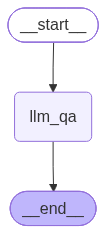

In [16]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())